<a href="https://colab.research.google.com/github/AventOOO/CountryAPI/blob/main/2253_%D0%96%D1%83%D0%BA%D0%BE%D0%B2_%D0%9C_%D0%9B_%D0%94%D0%A3%D0%9F%D0%97_%D0%94%D0%971.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Задание 1

Капля воды падает в воздухе и испытывает сопротивление воздуха, пропорциональное её скорости. Решить обыкновенное дифференциальное уравнение (ОДУ) аналитически (символьно) с помощью SymPy и построить график скорости относительно времени.

Модель капли в виде ОДУ была составлена на доске:
$$\frac{dv}{dt} = g - \frac{k}{m}v$$

Сейчас мы проделаем похожую работу, но вместо ручного аналитического решения попробуем смоделировать задачу на компьютере, а затем воспроизвести и аналитическое решение с помощью символьных вычислений в библиотеке **SymPy**.

### Задача 1

Опишите комментариями каждую строку кода и каждый параметр в вызванных библиотечных функциях.

**Подключение библиотек**

In [ ]:
# Библиотека для символьных вычислений
import sympy as sp
# Библиотека для численный массивов и операций
import numpy as np
# Библиотека для построения графиков
import matplotlib.pyplot as plt

**Определение констант**

In [ ]:
# k - коэффициент сопротивления воздуха, m - масса капли, g - ускорение свободного падения
k = 0.1
m = 1
g = 9.81

**Определение модели**

In [ ]:
# t - переменная времени
t = sp.symbols('t')
# v - неизвестная функция скорости от времени
v = sp.Function('v')

# ode - уравнение: dv/dt = g - (k/m)*v
# sp.Eq - функция для создания уравнения
# v(t).diff(t) - производная функции v(t) по времени t
ode = sp.Eq(v(t).diff(t), g - k/m*v(t))
ode

Eq(Derivative(v(t), t), 9.81 - 0.1*v(t))

**Начальное условие и временная сетка**

In [ ]:
# t0 - начальное время, v0 - начальная скорость, t_end - конечное время
t0 = 0
v0 = 0
t_end = 50

# t_space - массив значений времени от t0 до t_end с 500 точками
t_space = np.linspace(t0, t_end, 500)

**Решение задачи и график**

In [ ]:
# sp.dsolve - функция для решения дифференциального уравнения
# ode - уравнение, v(t) - неизвестная функция
# ics - начальные условия
solution = sp.dsolve(ode, v(t), ics={v(t0): v0})
solution

Eq(v(t), 98.1 - 98.1*exp(-0.1*t))

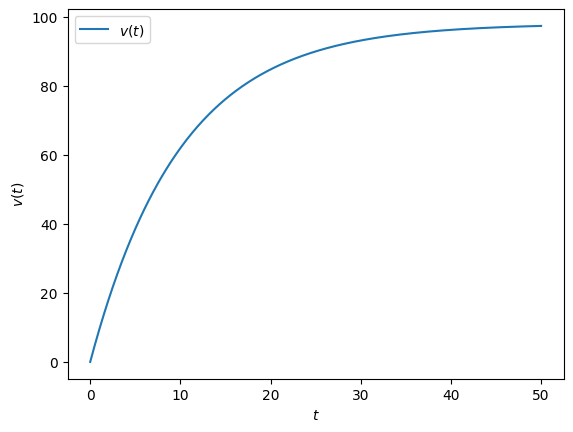

In [ ]:
# sp.lambdify - функция для преобразования символьного выражения в numpy-функцию
# solution.rhs - правая часть решения
v_func = sp.lambdify(t, solution.rhs, 'numpy')
# v_func - numpy-функция, представляющая решение во всех точках массива t_space
v_values = v_func(t_space)

# строим график зависимости скорости от времени
plt.plot(t_space, v_values, label=r'$v(t)$')
plt.xlabel(r'$t$')
plt.ylabel(r'$v(t)$')
plt.legend()
plt.show()

### Задача 2

Возьмите решение ОДУ, полученное аналитически у доски (вручную), запрограммируйте его и постройте график с двумя кривыми: символьным решением, полученным через SymPy (`solution`), и вашим "ручным" аналитическим решением. Кривую нужно определить по значениям функции $v(t)$ в заданных ранее точках по времени (`t_space`).

NB: обе кривые — это аналитические (точные) решения одного и того же ОДУ, полученные двумя разными способами: одно — компьютером через `dsolve`, другое — руками на бумаге. Цель задания — убедиться, что они совпадают.

In [ ]:
# Решение на основе полученной вручную (у доски) функции скорости от времени
v_analytical = (m * g / k) * (1 - np.exp(-(k / m) * t_space))


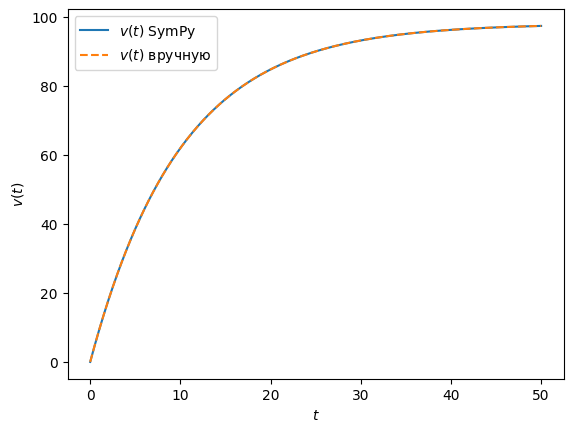

In [ ]:
plt.plot(t_space, v_values, label=r'$v(t)$ SymPy')
plt.plot(t_space, v_analytical, '--', label=r'$v(t)$ вручную')
plt.xlabel(r'$t$')
plt.ylabel(r'$v(t)$')
plt.legend()
plt.show()


## Задание 2

Горячий металлический шарик вынимают из печи, где он нагрелся до температуры $T_0$, и оставляют остывать в помещении с постоянной температурой воздуха $T_{env}$. Согласно закону теплообмена Ньютона, скорость изменения температуры тела пропорциональна разности между температурой тела и температурой окружающей среды.

### Вывод дифференциального уравнения

1. Пусть $T(t)$ — температура тела в момент времени $t$.
2. Закон Ньютона об охлаждении гласит, что скорость изменения температуры тела пропорциональна разности $T(t) - T_{env}$:
$$\frac{dT}{dt} \propto -\big(T(t) - T_{env}\big)$$
Знак минус — потому что тело остывает, если оно горячее среды ($T > T_{env}$, значит $dT/dt < 0$), и нагревается, если холоднее ($T < T_{env}$, значит $dT/dt > 0$).
3. Введём коэффициент теплоотдачи $h > 0$ (зависит от материала, площади поверхности шарика и условий конвекции воздуха):
$$\frac{dT}{dt} = -h\,\big(T(t) - T_{env}\big)$$
4. Получили линейное ОДУ первого порядка с постоянными коэффициентами — по структуре оно полностью аналогично уравнению для скорости капли из Задания 1 (там производная тоже линейно зависела от самой функции).

### Задача

По аналогии с Заданием 1:
1. Решите поставленное ОДУ аналитически на бумаге.
2. Задайте константы $h$, $T_{env}$, начальное условие $T(0) = T_0$ и временную сетку.
3. Получите аналитическое решение с помощью SymPy (`dsolve`) с учётом начального условия.
4. Постройте график кривой решения с помощью SymPy и "ручного" решения и убедитесь, что они совпадают.

Объявление констант:

In [ ]:
h = 0.10
T_env = 10.0
T0 = 150.0
t0 = 0
t_end = 200
t_space = np.linspace(t0, t_end, 500)

Задание уравнения:

In [ ]:
t = sp.symbols('t')
T = sp.Function('T')
ode = sp.Eq(T(t).diff(t), -h * (T(t) - T_env))
ode

Eq(Derivative(T(t), t), 1.0 - 0.1*T(t))

Решение уравнения, заданного питоном:

In [ ]:
solution = sp.dsolve(ode, T(t), ics={T(t0): T0})
solution

Eq(T(t), 10.0 + 140.0*exp(-0.1*t))

Получение значений функции на промежутке t_space:

In [ ]:
T_func = sp.lambdify(t, solution.rhs, 'numpy')
T_values = T_func(t_space)

Ввод аналитического решения в переменную:

In [ ]:
T_analytical = T_env + (T0 - T_env) * np.exp(-h * t_space)

Вывод:

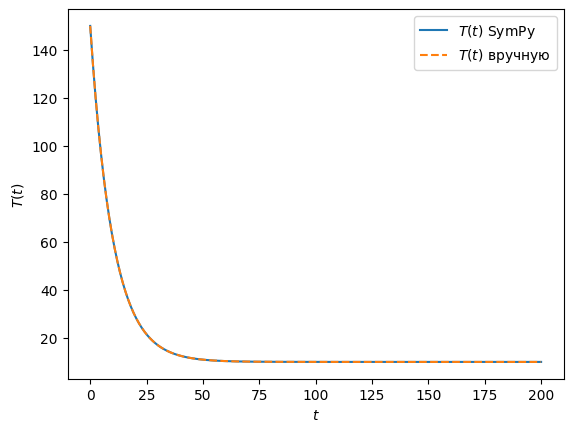

In [ ]:
plt.plot(t_space, T_values, label=r'$T(t)$ SymPy')
plt.plot(t_space, T_analytical, '--', label=r'$T(t)$ вручную')
plt.xlabel(r'$t$')
plt.ylabel(r'$T(t)$')
plt.legend()
plt.show()

## Задание 3

Конденсатор ёмкостью $C$ заряжается через резистор сопротивлением $R$ от источника постоянного напряжения $V_s$ (классическая RC-цепь). Нужно определить, как напряжение на конденсаторе $V(t)$ изменяется со временем в процессе зарядки.

### Вывод дифференциального уравнения

1. Пусть $V(t)$ — напряжение на конденсаторе в момент времени $t$, а $Q(t) = C\,V(t)$ — накопленный на его обкладках заряд.
2. По второму закону Кирхгофа (закон напряжений) сумма падений напряжения в контуре равна ЭДС источника:
$$V_s = I(t)\,R + V(t)$$
где $I(t)$ — ток зарядки, текущий через резистор.
3. Ток равен скорости прихода заряда на обкладки конденсатора:
$$I(t) = \frac{dQ}{dt} = C\,\frac{dV}{dt}$$
4. Подставляя выражение для тока в закон Кирхгофа, получаем:
$$V_s = RC\,\frac{dV}{dt} + V(t) \quad\Longrightarrow\quad \frac{dV}{dt} = \frac{V_s - V(t)}{RC}$$
5. Получили линейное ОДУ первого порядка с постоянными коэффициентами — той же структуры, что и в Заданиях 1 и 2: скорость изменения $V$ пропорциональна разности между текущим значением $V$ и "равновесным" значением $V_s$, к которому стремится напряжение (роль коэффициента $h$ из Задания 2 здесь играет $1/(RC)$).

### Задача

По аналогии с Заданиями 1 и 2:
1. Решите поставленное ОДУ аналитически на бумаге.
2. Задайте константы $R$, $C$, $V_s$, начальное условие $V(0) = V_0$ (например, разряженный конденсатор, $V_0 = 0$) и временную сетку.
3. Получите аналитическое решение с помощью SymPy (`dsolve`) с учётом начального условия.
4. Постройте график кривой решения с помощью SymPy и "ручного" решения и убедитесь, что они совпадают.

Объявление констант:

In [ ]:
R = 500.0
C = 0.001
Vs = 25.0
V0 = 0.0
t0 = 0
t_end = 20
t_space = np.linspace(t0, t_end, 500)

Задание уравнения:

In [ ]:
V = sp.Function('V')
t = sp.symbols('t')
ode = sp.Eq(V(t).diff(t), (Vs - V(t)) / (R * C))
ode

Eq(Derivative(V(t), t), 50.0 - 2.0*V(t))

Решение уравнения, заданного питоном:

In [ ]:
solution = sp.dsolve(ode, V(t), ics={V(t0): V0})
solution

Eq(V(t), 25.0 - 25.0*exp(-2.0*t))

Получение значений функции на промежутке t_space:

In [ ]:
V_func = sp.lambdify(t, solution.rhs, 'numpy')
V_values = V_func(t_space)

Ввод аналитического решения в переменную:

In [ ]:
V_analytical = Vs + (V0 - Vs) * np.exp(-t_space / (R * C))

Вывод:

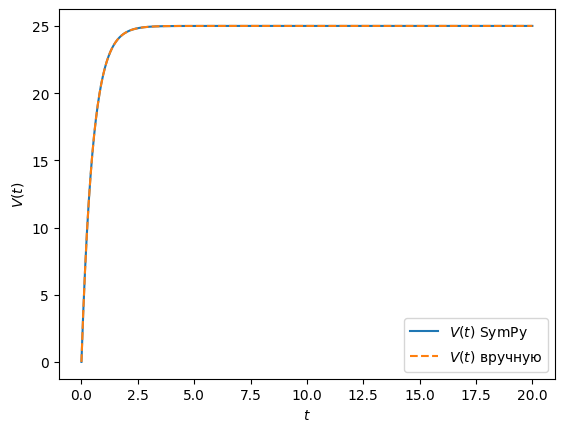

In [ ]:
plt.plot(t_space, V_values, label=r'$V(t)$ SymPy')
plt.plot(t_space, V_analytical, '--', label=r'$V(t)$ вручную')
plt.xlabel(r'$t$')
plt.ylabel(r'$V(t)$')
plt.legend()
plt.show()